In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ase.visualize import view
from ase.io import read

from skimage.io import imread, imsave
from skimage.draw import disk
from skimage.color import label2rgb

## Átomos de Carbono

In [2]:
graphene = read('graphene_defects.poscar')

In [3]:
view(graphene)

<Popen: returncode: None args: ['c:\\Users\\yasmin24023\\.conda\\envs\\ase_e...>

In [4]:
tem_img = imread('images/graphene_defects.tif').T
tem_img.shape

(3840, 4434)

In [5]:
imsave('images/graphene_defects.png',tem_img)

In [6]:
img_size = tem_img.shape
pixel_size = img_size / np.array([graphene.cell.array[0,0], graphene.cell.array[1,1]])
pixel_size

array([45.07042254, 45.06991362])

In [7]:
atoms_pixel_coords = np.rint(graphene.get_positions()[:,[0,1]] * pixel_size)

In [8]:
mask_img = np.ones((img_size[0],img_size[1], 1), dtype=int) * 0
mask_img.shape

(3840, 4434, 1)

In [9]:
atomic_radii = .41 #raio atomico do carbono

mask_radius = (pixel_size[1] * atomic_radii)
mask_radius

np.float64(18.47866458398923)

In [10]:
for io in range(len(atoms_pixel_coords)):
    rr, cc = disk((int(atoms_pixel_coords[io,0]), int(atoms_pixel_coords[io,1])), mask_radius, shape=mask_img.shape)
    mask_img[rr, cc, :] = 1

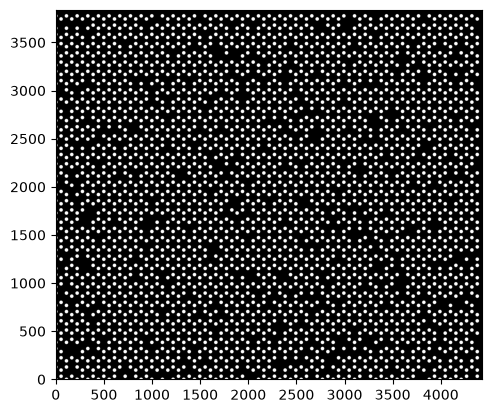

In [11]:
plt.imshow(mask_img,cmap='grey',origin='lower')

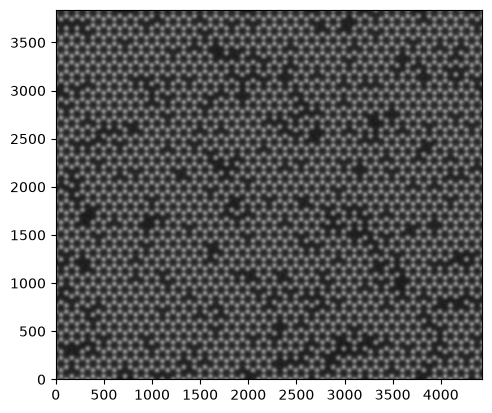

In [12]:
plt.imshow(tem_img,cmap='grey',origin='lower')

## Defeitos de Carbono

In [13]:
defects = read('graphene_defects_pos.poscar')

In [14]:
view(defects)

<Popen: returncode: None args: ['c:\\Users\\yasmin24023\\.conda\\envs\\ase_e...>

In [15]:
defects_pixel_coords = np.rint(defects.get_positions()[:,[0,1]] * pixel_size)

In [16]:
defects_mask_img = np.ones((img_size[0],img_size[1], 1), dtype=int) * 0
defects_mask_img.shape

(3840, 4434, 1)

In [17]:
for io in range(len(defects_pixel_coords)):
    rr, cc = disk((int(defects_pixel_coords[io,0]), int(defects_pixel_coords[io,1])), mask_radius, shape=defects_mask_img.shape)
    defects_mask_img[rr, cc, :] = 1

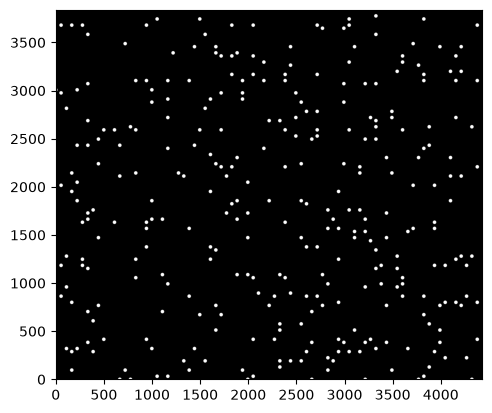

In [18]:
plt.imshow(defects_mask_img,cmap='grey',origin='lower')

### Salvar imagens

In [19]:
np.savez('graphene_labels.npz', **{'image': tem_img,'labels': mask_img, 'labels_defects': defects_mask_img})